<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/sparse_categorical_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, BatchNormalization, Activation
from keras.layers import MaxPooling1D, GlobalAveragePooling1D
from keras.layers import Dense, Add, Input
from keras.models import Model

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (87554, 188)


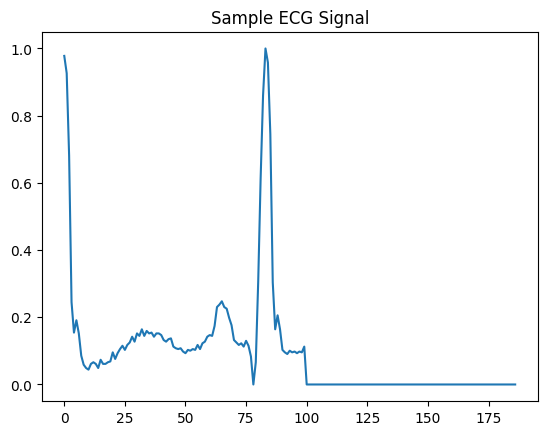

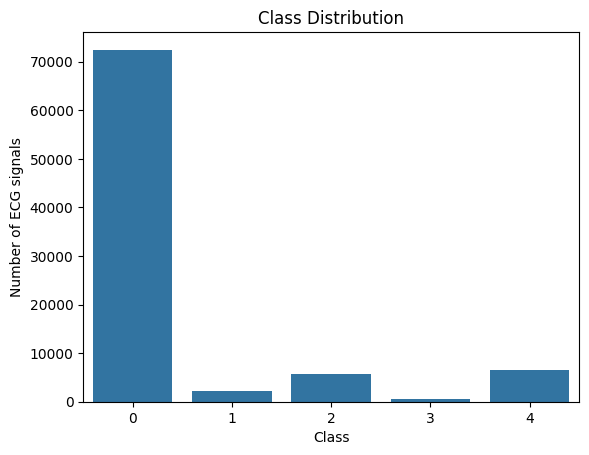

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [6]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [7]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [8]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [9]:
y_res_sparse = y_res
y_test_sparse = y_test

X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [10]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

In [11]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128,activation='relu')(x)
    outputs = Dense(5,activation='softmax')(x)

    model = Model(inputs,outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [12]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_sparse, test_size=0.2, random_state=42
)

In [14]:
model = resnet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1902s 418ms/step - accuracy: 0.9511 - loss: 0.1406 - val_accuracy: 0.8946 - val_loss: 0.3157
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1912s 411ms/step - accuracy: 0.9816 - loss: 0.0540 - val_accuracy: 0.9529 - val_loss: 0.1376
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1905s 416ms/step - accuracy: 0.9884 - loss: 0.0348 - val_accuracy: 0.8704 - val_loss: 0.4204
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1902s 420ms/step - accuracy: 0.9918 - loss: 0.0248 - val_accuracy: 0.9606 - val_loss: 0.1089
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1893s 418ms/step - accuracy: 0.9933 - loss: 0.0202 - val_accuracy: 0.9623 - val_loss: 0.1104
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1892s 418ms/step - accuracy: 0.9947 - loss: 0.0160 - val_accuracy: 0.9857 - val_loss: 0.0406
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1897s 419ms/step - accuracy: 0.9956 - loss: 0.0132 - val_accuracy: 0.9723 - val_loss: 0.0872
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 1907s 421ms/s

In [15]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)

val_mcc = matthews_corrcoef(y_val_final, y_val_pred)

print("Validation MCC:", val_mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 148s 64ms/step
Validation MCC: 0.990366548044254


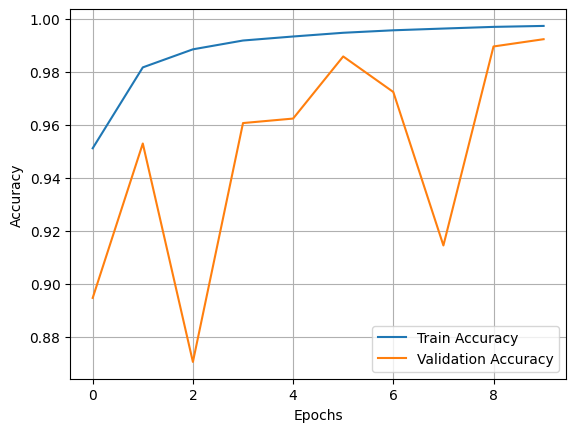

Final Training Accuracy: 0.9973
Final Validation Accuracy: 0.9923


In [16]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

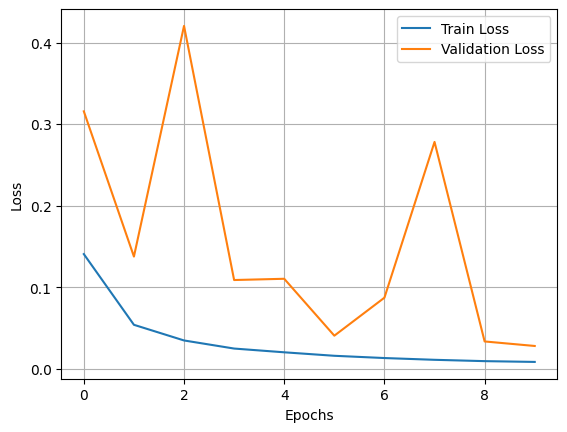

Final Training Loss: 0.0085
Final Validation Loss: 0.0280


In [17]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test_sparse, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.06706415861845016
Test Accuracy: 0.9781620502471924


In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_sparse, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

# ---- ADD THIS ONLY ----
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print("\nSpecificity per class:")

for i in range(len(cm)):
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + (np.sum(cm[i, :]) - TP))

    specificity = TN / (TN + FP)
    print(f"Class {i}: {specificity:.4f}")

Test Loss: 0.06706415861845016
Test Accuracy: 0.9781620502471924
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 130s 48ms/step
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99     72471
         1.0       0.65      1.00      0.79      2223
         2.0       0.96      1.00      0.98      5788
         3.0       0.66      1.00      0.79       641
         4.0       0.98      1.00      0.99      6431

    accuracy                           0.98     87554
   macro avg       0.85      0.99      0.91     87554
weighted avg       0.98      0.98      0.98     87554


Specificity per class:
Class 0: 0.9990
Class 1: 0.9860
Class 2: 0.9969
Class 3: 0.9962
Class 4: 0.9986


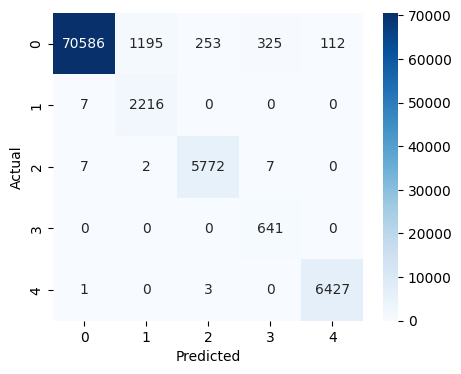

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_sparse.iloc[train_idx], y_res_sparse.iloc[val_idx]

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1454s 383ms/step - accuracy: 0.9450 - loss: 0.1557
Epoch 2/5
 642/3775 ━━━━━━━━━━━━━━━━━━━━ 23:06 443ms/step - accuracy: 0.9709 - loss: 0.0815

KeyboardInterrupt: 